In [ ]:
import matplotlib.pyplot as plt
import eng_to_heb
import json
import numpy as np
from scipy.stats import truncnorm

In [14]:
dev_data_path = '../datasets/mapped_datasets/mapped_dev.json'
train_data_path = '../datasets/mapped_datasets/mapped_train.json'
test_data_path = '../datasets/mapped_datasets/mapped_test.json'

datasets_path = [train_data_path]

In [17]:
def load_json_file(file_path):
    with open(file_path, 'r') as f:
        json_data = json.load(f)
    return json_data

In [18]:
data = []
for p in datasets_path:
    data+=load_json_file(p)


In [20]:
premises = [data[i]['premise_id'] for i in range(len(data))]
premises_text_ids = list(set(premises))

In [22]:
jsonl_path = 'unique_texts.jsonl.dlm2.0translated (1).jsonl'
translation_df = eng_to_heb.read_jsonl_file(jsonl_path)

In [23]:
translation_df['text_len'] = translation_df['text'].apply(len)
translation_df

,text,key,text_translated,text_len
0,100 Years of the Western Workplace Conditions ...,text_0,במהלך המאה ה-20 חלו שינויים משמעותיים בתנאי הע...,5038
1,Improvements in medicine led to workers earnin...,text_1,שיפורים ברפואה הובילו לכך שעובדים מרוויחים יות...,74
2,"In 1900, 19% of North American women of workin...",text_2,"בשנת 1900, 19% מהנשים בגיל העבודה בצפון אמריקה...",82
3,The appearance of shanty towns after farmers m...,text_3,הופעתן של שכונות עוני לאחר שחקלאים עוברים לאזו...,104
4,America and Europe shared the same overall tre...,text_4,אמריקה ואירופה חלקו את אותן מגמות כלליות בכל ה...,117
...,...,...,...,...
9625,Researches on animals indicate that virus coul...,text_9625,מחקרים בבעלי חיים מצביעים על כך שניתן להשתמש ב...,100
9626,John Hodges could have been at the club when t...,text_9626,ג'ון הודג'ס יכול היה להיות במועדון כאשר פרצה האש.,65
9627,The flat where the plan was found is close to ...,text_9627,הדירה שבה נמצא התכנון קרובה למועדון.,55
9628,A member of John Hodges' family died in the blaze,text_9628,בן משפחתו של ג'ון הודג'ס מת בשריפה.,49


<Axes: title={'center': 'All premises+hypothesis text lengths'}, xlabel='text length', ylabel='#texts'>

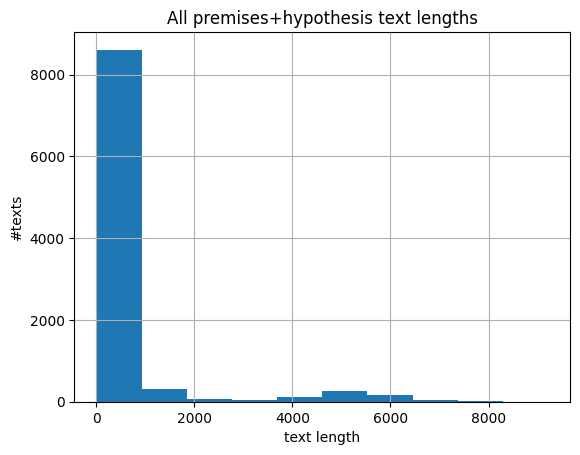

In [53]:
plt.title('All premises+hypothesis text lengths')
plt.xlabel('text length')
plt.ylabel('#texts')
translation_df.text_len.hist()

In [25]:
premises_translation_df = translation_df[translation_df['key'].isin(premises_text_ids)]

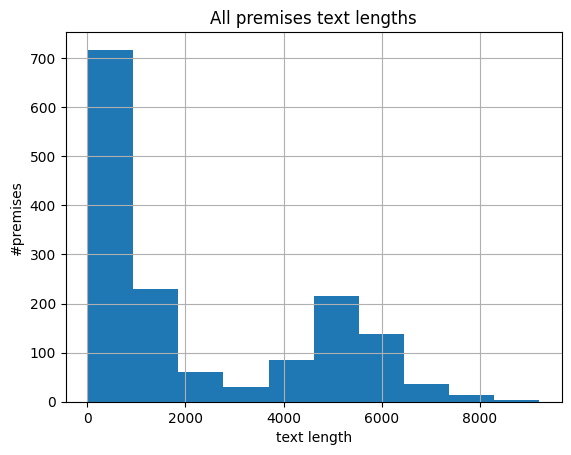

In [54]:
plt.title('All premises text lengths')
plt.xlabel('text length')
plt.ylabel('#premises')
premises_translation_df.text_len.hist()
plt.show()

In [28]:
mean_length = premises_translation_df['text_len'].mean()
std_dev_length = premises_translation_df['text_len'].std()
mean_length, std_dev_length

(2309.98431372549, 2270.942958324376)

In [31]:
np.random.seed(0)

lower_bound = 0
# Sample from a truncated normal distribution
num_samples = 40  # Specify how many samples you want
samples = truncnorm.rvs(
    (lower_bound - mean_length) / std_dev_length,
    (7000 - mean_length) / std_dev_length,
    loc=mean_length,
    scale=std_dev_length,
    size=num_samples,
)

(array([4., 2., 1., 6., 8., 6., 5., 3., 2., 3.]),
 array([ 143.59462643,  765.64821874, 1387.70181105, 2009.75540336,
        2631.80899567, 3253.86258798, 3875.91618029, 4497.96977261,
        5120.02336492, 5742.07695723, 6364.13054954]),
 <BarContainer object of 10 artists>)

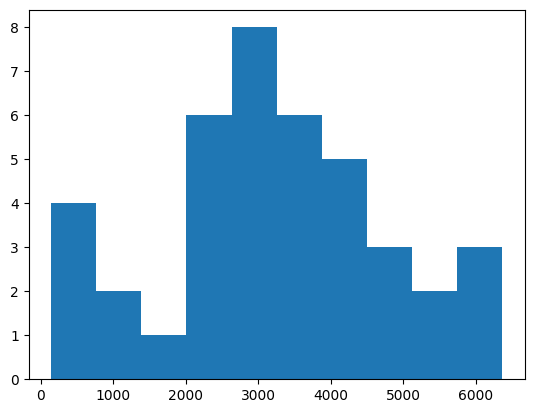

In [33]:
plt.hist(samples)

In [34]:
rounded_samples = samples.round()
rounded_samples, len(rounded_samples)

(array([2932., 3808., 3200., 2912., 2335., 3424., 2401., 5109., 6057.,
        2146., 4291., 2835., 3026., 5487.,  504.,  606.,  154., 4590.,
        4199., 4902., 6364., 4343., 2514., 4215.,  794., 3392.,  938.,
        5746., 2801., 2293., 1575., 4174., 2488., 3028.,  144., 3276.,
        3247., 3272., 5732., 3618.]),
 40)

In [35]:
# rounded_samples
used_ids = set()
selected_ids = []

In [36]:
for sample in rounded_samples:
    # Filter out used IDs from the DataFrame
    available_df = premises_translation_df[~premises_translation_df['key'].isin(used_ids)]
    
    if available_df.empty:
        break  # Stop if there are no available IDs left

    closest_row = available_df.iloc[(available_df['text_len'] - sample).abs().argsort()[:1]]
    closest_id = closest_row['key'].values[0]
    
    selected_ids.append(closest_id)
    used_ids.add(closest_id)

In [37]:
len(selected_ids)

40

In [56]:
chosen_df = premises_translation_df[premises_translation_df.key.isin(selected_ids)].sample(frac=1).reset_index(drop=True)

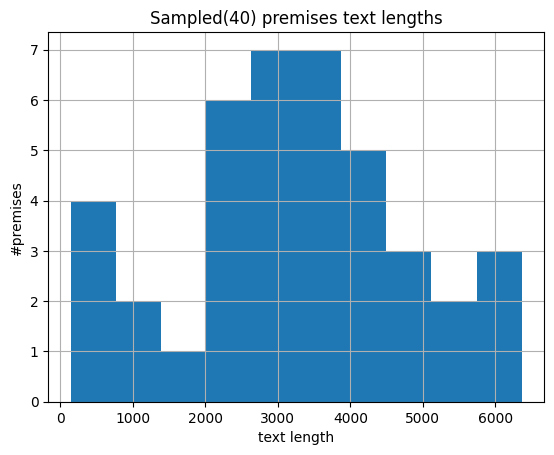

In [60]:
plt.title(f'Sampled({chosen_df.shape[0]}) premises text lengths')
plt.xlabel('text length')
plt.ylabel('#premises')
chosen_df.text_len.hist()
plt.show()

In [39]:
# def extract_pairs_related_to_premise_text_id
import pandas as pd
pairs_data = pd.DataFrame(data)
chosen_pairs_data = pairs_data[pairs_data.premise_id.isin(selected_ids)].reset_index(drop=True)
chosen_pairs_data

,uid,premise_id,hypothesis_id,label
0,id_299,text_345,text_346,e
1,id_300,text_345,text_347,n
2,id_301,text_345,text_348,n
3,id_302,text_345,text_349,c
4,id_722,text_865,text_866,n
...,...,...,...,...
220,id_6612,text_7637,text_7639,e
221,id_6613,text_7637,text_7640,c
222,id_6614,text_7637,text_7641,e
223,id_6615,text_7637,text_7642,e


In [40]:
translation_df

,text,key,text_translated,text_len
0,100 Years of the Western Workplace Conditions ...,text_0,במהלך המאה ה-20 חלו שינויים משמעותיים בתנאי הע...,5038
1,Improvements in medicine led to workers earnin...,text_1,שיפורים ברפואה הובילו לכך שעובדים מרוויחים יות...,74
2,"In 1900, 19% of North American women of workin...",text_2,"בשנת 1900, 19% מהנשים בגיל העבודה בצפון אמריקה...",82
3,The appearance of shanty towns after farmers m...,text_3,הופעתן של שכונות עוני לאחר שחקלאים עוברים לאזו...,104
4,America and Europe shared the same overall tre...,text_4,אמריקה ואירופה חלקו את אותן מגמות כלליות בכל ה...,117
...,...,...,...,...
9625,Researches on animals indicate that virus coul...,text_9625,מחקרים בבעלי חיים מצביעים על כך שניתן להשתמש ב...,100
9626,John Hodges could have been at the club when t...,text_9626,ג'ון הודג'ס יכול היה להיות במועדון כאשר פרצה האש.,65
9627,The flat where the plan was found is close to ...,text_9627,הדירה שבה נמצא התכנון קרובה למועדון.,55
9628,A member of John Hodges' family died in the blaze,text_9628,בן משפחתו של ג'ון הודג'ס מת בשריפה.,49


In [41]:
premise_df = chosen_pairs_data.merge(
    translation_df,
    left_on='premise_id',
    right_on='key',
    how='left')

premise_df

,uid,premise_id,hypothesis_id,label,text,key,text_translated,text_len
0,id_299,text_345,text_346,e,A robbery was committed at a Post Office on th...,text_345,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",606
1,id_300,text_345,text_347,n,A robbery was committed at a Post Office on th...,text_345,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",606
2,id_301,text_345,text_348,n,A robbery was committed at a Post Office on th...,text_345,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",606
3,id_302,text_345,text_349,c,A robbery was committed at a Post Office on th...,text_345,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",606
4,id_722,text_865,text_866,n,Almost everyone with or without a computer is ...,text_865,"כמעט כל אדם, עם או בלי מחשב, מודע למהפכה הטכנו...",2483
...,...,...,...,...,...,...,...,...
220,id_6612,text_7637,text_7639,e,"The Vitamin Shoppe: 1,946 part-time openings T...",text_7637,"The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",2758
221,id_6613,text_7637,text_7640,c,"The Vitamin Shoppe: 1,946 part-time openings T...",text_7637,"The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",2758
222,id_6614,text_7637,text_7641,e,"The Vitamin Shoppe: 1,946 part-time openings T...",text_7637,"The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",2758
223,id_6615,text_7637,text_7642,e,"The Vitamin Shoppe: 1,946 part-time openings T...",text_7637,"The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",2758


In [42]:
# Merge the origin_df with the translation_df for hypotheses
hypothesis_df = chosen_pairs_data.merge(
    translation_df,
    left_on='hypothesis_id',
    right_on='key',
    how='left',
)
hypothesis_df

,uid,premise_id,hypothesis_id,label,text,key,text_translated,text_len
0,id_299,text_345,text_346,e,The rucksack may have belonged to Alan.,text_346,התיק עשוי היה להיות שייך לאלן.,39
1,id_300,text_345,text_347,n,Alan will now be able to pay off all his debts.,text_347,אלן יוכל עתה לפרוע את כל חובותיו.,47
2,id_301,text_345,text_348,n,Alan wouldnt have been able to drive away.,text_348,אלן לא היה יכול לנסוע.,42
3,id_302,text_345,text_349,c,Jason committed the robbery.,text_349,יסון ביצע את השוד.,28
4,id_722,text_865,text_866,n,Using the Internet costs the owner of a teleph...,text_866,שימוש באינטרנט עולה לבעל הטלפון כסף נוסף.,62
...,...,...,...,...,...,...,...,...
220,id_6612,text_7637,text_7639,e,None of the offers included an approximate sal...,text_7639,אף אחת מן ההצעות לא כללה שכר משוער בתיאור.,69
221,id_6613,text_7637,text_7640,c,Advantage Sales & Marketing owns 65 offices al...,text_7640,חברת Advantage Sales & Marketing מחזיקה 65 סני...,63
222,id_6614,text_7637,text_7641,e,The Vitamin Shoppe has an above average salary...,text_7641,"בחנות הוויטמינים משתכרים מעל הממוצע, לפי הביקורת.",72
223,id_6615,text_7637,text_7642,e,Reviewer of the company Chipotle says that wor...,text_7642,מבקרת החברה Chipotle אומרת שעבודה שם היא גם מה...,92


In [43]:
final_df = pd.DataFrame({
    'premise_text_key': premise_df['key'],
    'uid': premise_df['uid'],
    'english_premise': premise_df['text'],
    'hebrew_premise': premise_df['text_translated'],
    'english_hypothesis': hypothesis_df['text'],
    'hebrew_hypothesis': hypothesis_df['text_translated'],
    'label': chosen_pairs_data['label'],
    'premise_text_len': premise_df['text_len']
})
final_df

,premise_text_key,uid,english_premise,hebrew_premise,english_hypothesis,hebrew_hypothesis,label,premise_text_len
0,text_345,id_299,A robbery was committed at a Post Office on th...,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",The rucksack may have belonged to Alan.,התיק עשוי היה להיות שייך לאלן.,e,606
1,text_345,id_300,A robbery was committed at a Post Office on th...,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",Alan will now be able to pay off all his debts.,אלן יוכל עתה לפרוע את כל חובותיו.,n,606
2,text_345,id_301,A robbery was committed at a Post Office on th...,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",Alan wouldnt have been able to drive away.,אלן לא היה יכול לנסוע.,n,606
3,text_345,id_302,A robbery was committed at a Post Office on th...,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",Jason committed the robbery.,יסון ביצע את השוד.,c,606
4,text_865,id_722,Almost everyone with or without a computer is ...,"כמעט כל אדם, עם או בלי מחשב, מודע למהפכה הטכנו...",Using the Internet costs the owner of a teleph...,שימוש באינטרנט עולה לבעל הטלפון כסף נוסף.,n,2483
...,...,...,...,...,...,...,...,...
220,text_7637,id_6612,"The Vitamin Shoppe: 1,946 part-time openings T...","The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",None of the offers included an approximate sal...,אף אחת מן ההצעות לא כללה שכר משוער בתיאור.,e,2758
221,text_7637,id_6613,"The Vitamin Shoppe: 1,946 part-time openings T...","The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",Advantage Sales & Marketing owns 65 offices al...,חברת Advantage Sales & Marketing מחזיקה 65 סני...,c,2758
222,text_7637,id_6614,"The Vitamin Shoppe: 1,946 part-time openings T...","The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",The Vitamin Shoppe has an above average salary...,"בחנות הוויטמינים משתכרים מעל הממוצע, לפי הביקורת.",e,2758
223,text_7637,id_6615,"The Vitamin Shoppe: 1,946 part-time openings T...","The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",Reviewer of the company Chipotle says that wor...,מבקרת החברה Chipotle אומרת שעבודה שם היא גם מה...,e,2758


In [44]:
from eng_to_heb_processes.eng_to_heb import get_sampled_translations_according_to_premises_lengths

dev_data_path = '../datasets/mapped_datasets/mapped_dev.json'
train_data_path = '../datasets/mapped_datasets/mapped_train.json'
test_data_path = '../datasets/mapped_datasets/mapped_test.json'

mappings_datasets_path = [train_data_path]
tran_path = 'unique_texts.jsonl.dlm2.0translated (1).jsonl'
df = get_sampled_translations_according_to_premises_lengths(translation_jsonl_path=tran_path,
                                                            mappings_files_paths_list=mappings_datasets_path,
                                                            num_samples=40)

In [45]:
import numpy as np
df

,premise_text_key,uid,english_premise,hebrew_premise,english_hypothesis,hebrew_hypothesis,label,premise_text_len
0,text_345,id_299,A robbery was committed at a Post Office on th...,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",The rucksack may have belonged to Alan.,התיק עשוי היה להיות שייך לאלן.,e,606
1,text_345,id_300,A robbery was committed at a Post Office on th...,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",Alan will now be able to pay off all his debts.,אלן יוכל עתה לפרוע את כל חובותיו.,n,606
2,text_345,id_301,A robbery was committed at a Post Office on th...,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",Alan wouldnt have been able to drive away.,אלן לא היה יכול לנסוע.,n,606
3,text_345,id_302,A robbery was committed at a Post Office on th...,"בוצעה שוד בסניף דואר בבוקר ה-19 באפריל, 3,265 ...",Jason committed the robbery.,יסון ביצע את השוד.,c,606
4,text_865,id_722,Almost everyone with or without a computer is ...,"כמעט כל אדם, עם או בלי מחשב, מודע למהפכה הטכנו...",Using the Internet costs the owner of a teleph...,שימוש באינטרנט עולה לבעל הטלפון כסף נוסף.,n,2483
...,...,...,...,...,...,...,...,...
220,text_7637,id_6612,"The Vitamin Shoppe: 1,946 part-time openings T...","The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",None of the offers included an approximate sal...,אף אחת מן ההצעות לא כללה שכר משוער בתיאור.,e,2758
221,text_7637,id_6613,"The Vitamin Shoppe: 1,946 part-time openings T...","The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",Advantage Sales & Marketing owns 65 offices al...,חברת Advantage Sales & Marketing מחזיקה 65 סני...,c,2758
222,text_7637,id_6614,"The Vitamin Shoppe: 1,946 part-time openings T...","The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",The Vitamin Shoppe has an above average salary...,"בחנות הוויטמינים משתכרים מעל הממוצע, לפי הביקורת.",e,2758
223,text_7637,id_6615,"The Vitamin Shoppe: 1,946 part-time openings T...","The Vitamin Shoppe: 1,946 משרות חלקיות פתוחות ...",Reviewer of the company Chipotle says that wor...,מבקרת החברה Chipotle אומרת שעבודה שם היא גם מה...,e,2758


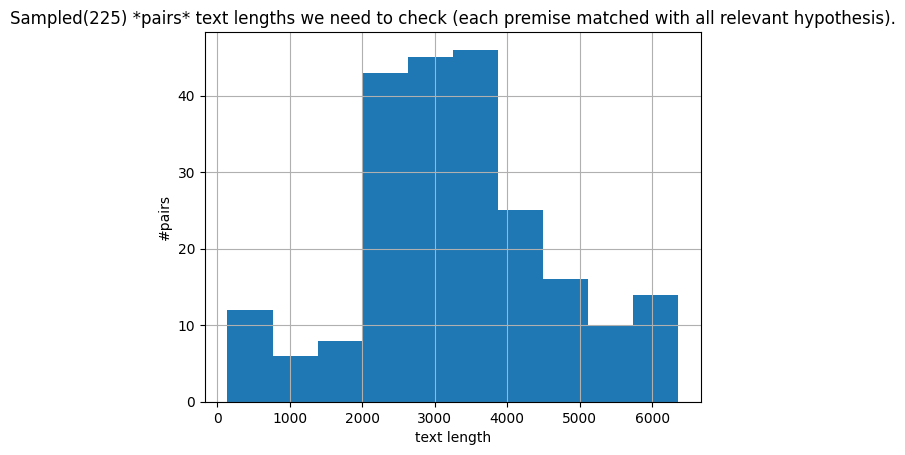

In [66]:
plt.title(f'Sampled({df.shape[0]}) *pairs* text lengths we need to check (each premise matched with all relevant hypothesis).')
plt.xlabel('text length')
plt.ylabel('#pairs')
df.premise_text_len.hist()
plt.show()